# Part 1: Dogs vs Cats Under Tile Orders
This notebook trains three image-classification architecture families on Dogs vs Cats.
It evaluates how fixed tile-wise tile permutations affect validation accuracy.
Results are aggregated by tile count and plotted as accuracy vs number of tiles.


## Setup

### Global / External Imports
Import third-party libraries used only for notebook orchestration and display.


most basic imports

In [1]:
from pathlib import Path
import importlib
import os
import sys


### Local Imports
Import project modules. Part 1 orchestration lives in this notebook; reusable training, preprocessing, and evaluation helpers stay in `src`.


prep for local imports

In [2]:
from pathlib import Path
import importlib
import importlib.util

_REQUIRED_PROJECT_FILES = (
    Path('src/__init__.py'),
    Path('src/utils/notebook_setup.py'),
    Path('src/evaluation/experiment_results.py'),
)

_CANDIDATE_PROJECT_ROOTS = (
    Path('/content/drive/MyDrive/MLDS_Final_Project'),
    Path('/content/MLDS_Final_Project'),
    Path('/content/drive/MyDrive/Colab Notebooks/MLDS_Final_Project'),
)


def _safe_resolve(path):
    try:
        return Path(path).resolve()
    except OSError:
        return None


def _safe_exists(path):
    try:
        return Path(path).exists()
    except OSError:
        return False


def _safe_cwd():
    try:
        return Path.cwd().resolve()
    except OSError:
        fallback = Path('/content')
        return fallback if _safe_exists(fallback) else Path.home()


def _safe_glob(path, pattern):
    try:
        return list(path.glob(pattern))
    except OSError:
        return []


def _path_looks_like_project_root(path):
    try:
        return all((path / required).is_file() for required in _REQUIRED_PROJECT_FILES)
    except OSError:
        return False


def _candidate_project_roots():
    current = _safe_cwd()
    candidates = [current, *current.parents, *_CANDIDATE_PROJECT_ROOTS]
    my_drive = Path('/content/drive/MyDrive')
    if _safe_exists(my_drive):
        candidates.extend(_safe_glob(my_drive, 'MLDS_Final_Project'))
        candidates.extend(_safe_glob(my_drive, '*/MLDS_Final_Project'))
    return candidates


def _find_project_root():
    seen = set()
    for candidate in _candidate_project_roots():
        candidate = _safe_resolve(candidate)
        if candidate is None or candidate in seen:
            continue
        seen.add(candidate)
        if _path_looks_like_project_root(candidate):
            return candidate
    return None


def _mount_colab_drive_if_available():
    try:
        from google.colab import drive  # type: ignore
    except ImportError:
        return
    drive.mount('/content/drive', force_remount=True)


_PROJECT_ROOT = _find_project_root()
if _PROJECT_ROOT is None:
    _mount_colab_drive_if_available()
    _PROJECT_ROOT = _find_project_root()

if _PROJECT_ROOT is None:
    raise ModuleNotFoundError(
        'Could not find the full MLDS_Final_Project repo. Expected '
        'src/__init__.py, src/utils/notebook_setup.py, and '
        'src/evaluation/experiment_results.py. In Colab, upload or clone '
        'the full repo, or place it at /content/drive/MyDrive/MLDS_Final_Project.'
    )

_COLAB_UTILS_PATH = _PROJECT_ROOT / 'src' / 'utils' / 'colab.py'
_COLAB_SPEC = importlib.util.spec_from_file_location('_mlds_colab_bootstrap', _COLAB_UTILS_PATH)
if _COLAB_SPEC is None or _COLAB_SPEC.loader is None:
    raise ImportError(f'Could not load Colab bootstrap helpers from {_COLAB_UTILS_PATH}')
_colab_bootstrap = importlib.util.module_from_spec(_COLAB_SPEC)
_COLAB_SPEC.loader.exec_module(_colab_bootstrap)

ROOT = _colab_bootstrap.bootstrap_notebook_runtime(_PROJECT_ROOT, force_remount=False)
notebook_setup = importlib.import_module('src.utils.notebook_setup')
ROOT


Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Python: 3.12.13
Package versions:
  numpy: 2.0.2
  pandas: 2.2.2
  scipy: 1.16.3
  scikit-learn: 1.6.1
  torch: 2.11.0+cu128
  torchvision: 0.26.0+cu128
  timm: 1.0.27
  pyyaml: 6.0.3
torch.cuda.is_available(): True
CUDA device: NVIDIA L4
Project root: /content/drive/MyDrive/MLDS_Final_Project


PosixPath('/content/drive/MyDrive/MLDS_Final_Project')

make local imports

In [3]:
import pandas as pd
from IPython.core.display import Image
from IPython.display import display

import src.evaluation.experiment_results as experiment_results

experiment_results = importlib.reload(experiment_results)
from src.utils.reproducibility import seed_everything  # noqa: E402


### Setup configs

In [4]:
import src.models.factory as model_factory
import src.training.trainer as trainer_module
import src.utils.plotting as plotting
import src.experiments.part1 as part1_experiments

model_factory = importlib.reload(model_factory)
trainer_module = importlib.reload(trainer_module)
plotting = importlib.reload(plotting)
part1_experiments = importlib.reload(part1_experiments)

load_experiment_samples = experiment_results.load_experiment_samples
stage_configured_colab_data_dir = experiment_results.stage_configured_colab_data_dir
plot_accuracy_vs_tiles = experiment_results.plot_accuracy_vs_tiles
experiment_intermediate_figure_path = experiment_results.experiment_intermediate_figure_path
save_aggregated_accuracy = experiment_results.save_aggregated_accuracy
save_rows = experiment_results.save_rows
train_model_on_tile_permutation_records = part1_experiments.train_model_on_tile_permutation_records
plot_tile_permutation_samples = plotting.plot_tile_permutation_samples
from src.preprocessing.samples import class_counts  # noqa: E402
from src.preprocessing.tile_permutations import build_tile_permutation_records, matrix_to_flat_order, tile_permutation_to_jsonable  # noqa: E402
from src.utils.io import save_csv  # noqa: E402


In [5]:
part1_setup = notebook_setup.setup_part1_config()
configs = part1_setup.configs
configs.num_tile_permutations = 3  # Keep easy, medium, and hard in local sample/table output.
configs.stage_colab_data_to_local_disk = True  # Set False on Colab to read directly from Drive instead of copying to /content.
device = part1_setup.device


Running on Google Colab, adjusting configs...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Selected device: cuda
Python: 3.12.13
Package versions:
  numpy: 2.0.2
  pandas: 2.2.2
  scipy: 1.16.3
  scikit-learn: 1.6.1
  torch: 2.11.0+cu128
  torchvision: 0.26.0+cu128
  timm: 1.0.27
  pyyaml: 6.0.3
torch.cuda.is_available(): True
CUDA device: NVIDIA L4
Selected device: cuda


In [6]:
print(configs)


CVExperimentConfig(part='part1', config_name='part1', device='auto', deterministic=False, root_dir='/content/drive/MyDrive/MLDS_Final_Project', data_dir='/content/drive/MyDrive/MLDS_Final_Project/data/dogs-vs-cats/train', outputs_dir='/content/drive/MyDrive/MLDS_Final_Project/outputs', results_dir='/content/drive/MyDrive/MLDS_Final_Project/outputs/results', figures_dir='/content/drive/MyDrive/MLDS_Final_Project/outputs/figures', sample_data=False, sample_limit=256, val_fraction=0.2, test_fraction=0.0, image_size=224, batch_size=64, num_workers=4, num_classes=2, model_names=['resnet18', 'deit_tiny', 'mlp_mixer_base'], pretrained=True, freeze_backbone=True, tiles_per_side_values=[1, 4, 7, 10], num_tile_permutations=3, epochs=10, learning_rate=0.0003, optimizer='adamw', weight_decay=0.0001, use_amp=True, seed=42, max_threads=4, using_google_colab=True, plot_samples=False, stage_colab_data_to_local_disk=True, colab_local_data_dir='/content/MLDS_Final_Project/data/dogs-vs-cats/train', profi

In [7]:
%%time
configs.data_dir = stage_configured_colab_data_dir(configs)
print(f'Active data_dir: {configs.data_dir}')


Starting Colab dataset staging.
  Source data directory: /content/drive/MyDrive/MLDS_Final_Project/data/dogs-vs-cats/train
  Expected source ZIP: /content/drive/MyDrive/MLDS_Final_Project/data/dogs-vs-cats/train.zip
  Local ZIP destination: /content/MLDS_Final_Project/data/dogs-vs-cats/train.zip
  Local extraction directory: /content/MLDS_Final_Project/data/dogs-vs-cats/train
  Source directory labeled images: 25000
  Source ZIP labeled images: 25000
  Existing local labeled images: 0
Copying dataset ZIP from Google Drive to local Colab disk: /content/drive/MyDrive/MLDS_Final_Project/data/dogs-vs-cats/train.zip -> /content/MLDS_Final_Project/data/dogs-vs-cats/train.zip (547.8 MiB)
Finished copying dataset ZIP in 18.09s.
Extracting 25000 labeled images from /content/MLDS_Final_Project/data/dogs-vs-cats/train.zip into /content/MLDS_Final_Project/data/dogs-vs-cats/train.
Finished extracting Colab dataset: 25000 files extracted in 3.75s; 25000 labeled images now available locally.
Finished

Local runs use a balanced 256-image subset and 5 training epochs. With `val_fraction=0.2`, the validation split is large enough for accuracy to move in smaller steps than the old 6-image smoke-test split. In aggregated results, `final_epoch` means the metric from the last epoch, and `best_epoch` means the best validation score observed during training.

### make installations before final external imports

In [8]:
# Dependencies are installed during the setup/bootstrap cell above when running in Colab.
print('Dependency setup is complete.')


Dependency setup is complete.


### final imports (after doing pip install if working on colab)

In [9]:
import json
import random
from IPython.core.display import Image
from IPython.display import display
import pandas as pd
import numpy as np
import torch


## Experiments

### Experiment helpers
Shared helpers are kept in `src/evaluation/experiment_results.py`; notebook-specific helpers stay here.

In [10]:
# Part 1 output paths are prepared by notebook_setup.setup_part1_config().


### Setup Exp

In [11]:
# 4. Reproducibility (important for multiple notebooks
random.seed(configs.seed)
np.random.seed(configs.seed)
torch.manual_seed(configs.seed)
torch.set_num_threads(configs.max_threads)  # avoid contention across notebooks

In [12]:
output_paths = part1_setup.output_paths
output_paths


{'raw_results': '/content/drive/MyDrive/MLDS_Final_Project/outputs/results/part1_raw_results.csv',
 'aggregated_results': '/content/drive/MyDrive/MLDS_Final_Project/outputs/results/part1_aggregated_results.csv',
 'figure': '/content/drive/MyDrive/MLDS_Final_Project/outputs/figures/part1_accuracy_vs_tiles.png',
 'intermediate_figures_dir': '/content/drive/MyDrive/MLDS_Final_Project/outputs/figures/intermediate',
 'tile_permutations': '/content/drive/MyDrive/MLDS_Final_Project/outputs/results/part1_tile_permutations.csv',
 'accuracy_plot': '/content/drive/MyDrive/MLDS_Final_Project/outputs/figures/part1_accuracy_vs_tiles.png'}

### Data Loading
Discover the configured Dogs vs Cats split before training.


In [13]:
train_samples, validation_samples, test_samples = load_experiment_samples(config=configs, seed=configs.seed)
print(f'Train samples: {len(train_samples)}')
print(f'Validation samples: {len(validation_samples)}')
print(f'Test samples: {len(test_samples)}')
print('Train class counts:', class_counts(samples=train_samples))
print('Validation class counts:', class_counts(samples=validation_samples))
print('Test class counts:', class_counts(samples=test_samples))

Train samples: 20000
Validation samples: 5000
Test samples: 0
Train class counts: {'cat': 10000, 'dog': 10000}
Validation class counts: {'cat': 2500, 'dog': 2500}
Test class counts: {'cat': 0, 'dog': 0}


### Experiments - Run Baselines
Run the configured baseline grid/model/tile permutation sweep. Re-run this cell to regenerate Part 1 outputs.


In [14]:
# Build and save tile permutation records
tile_permutation_records = build_tile_permutation_records(
    tiles_per_side_values=configs.tiles_per_side_values,
    num_tile_permutations=configs.num_tile_permutations,
    seed=configs.seed,
    include_baseline=True,
)
tile_permutation_rows = [
    record.__dict__ | {'tile_permutation': json.dumps(tile_permutation_to_jsonable(record.tile_permutation))}
    for record in tile_permutation_records
]
save_csv(data=tile_permutation_rows, path=output_paths['tile_permutations'])
print(f"Saved {len(tile_permutation_records)} tile permutation records")

permutation_examples = []
for record in tile_permutation_records:
    grid_label = '1x1 / None' if record.tiles_per_side is None else f'{record.tiles_per_side}x{record.tiles_per_side}'
    flat_order = None if record.tile_permutation is None else matrix_to_flat_order(record.tile_permutation)
    permutation_examples.append(
        {
            'grid': grid_label,
            'num_tiles': 1 if record.tiles_per_side is None else record.tiles_per_side * record.tiles_per_side,
            'difficulty': record.tile_permutation_name,
            'tile_permutation_id': record.tile_permutation_id,
            'flat_order_preview': 'None' if flat_order is None else flat_order[: min(12, len(flat_order))],
        }
    )
display(pd.DataFrame(permutation_examples))

if configs.plot_samples:
    import matplotlib.pyplot as plt

    plot_tile_permutation_samples(
        samples=train_samples,
        tile_permutation_records=tile_permutation_records,
        image_size=configs.image_size,
        samples_per_class=1,
        max_records=sum(1 for record in tile_permutation_records if record.tile_permutation is not None),
    )
    plt.show()


Saved 12 tile permutation records


,grid,num_tiles,difficulty,tile_permutation_id,flat_order_preview
0,1x1 / None,1,easy,1,None
1,1x1 / None,1,medium,2,None
2,1x1 / None,1,hard,3,None
3,4x4,16,easy,1,"[1, 0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
4,4x4,16,medium,2,"[6, 5, 7, 4, 9, 10, 11, 8, 13, 14, 2, 12]"
5,4x4,16,hard,3,"[14, 9, 8, 13, 6, 5, 4, 12, 3, 1, 0, 2]"
6,7x7,49,easy,1,"[1, 0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
7,7x7,49,medium,2,"[24, 9, 10, 47, 17, 13, 7, 15, 16, 12, 18, 19]"
8,7x7,49,hard,3,"[17, 28, 13, 25, 22, 10, 21, 16, 7, 1, 20, 11]"
9,10x10,100,easy,1,"[1, 0, 2, 3, 4, 5, 7, 6, 8, 9, 10, 11]"


In [15]:
# Setup reproducibility and load data
seed = configs.seed
seed_everything(seed=seed, deterministic=configs.deterministic)
# Data already loaded above
print(f"Loaded {len(train_samples)} train, {len(validation_samples)} val samples")

Loaded 20000 train, 5000 val samples


In [16]:
# Prepare shared result accumulation across model runs
all_rows = []
run_id = configs.config_name

### Train Lightweight Model Trio
Train the configured pretrained trio: ResNet-18, DeiT-Tiny, and MLP-Mixer Small.

Saved 12 pending row(s) for model 'resnet18'.

[1/12]
model=resnet18, tiles_per_side=None, tile_permutation_id=1, tile_permutation_name=easy, seed=42
stages=1
1. standard: 10 epochs
Building dataloaders...
Built dataloaders: 
	train=20000 samples in 313 batches
	validation=5000 samples in 79 batches.
Building model 'resnet18'...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 238MB/s]


Runtime: selected_device=cuda, model_device=cuda:0, use_amp=True, amp_enabled=True, cuda_device=NVIDIA L4
Model summary: model=resnet18, total_params=11,177,538, trainable_params=1,026, optimizer_params=1,026, freeze_backbone=True
Checkpoint complete; skipping step at epoch 10/10: /content/drive/MyDrive/MLDS_Final_Project/outputs/checkpoints/part1/part1/resnet18__tiles_1__perm_1__last.pt
Current run runtime: 8s
Total training runtime: 9s

[2/12]
model=resnet18, tiles_per_side=None, tile_permutation_id=2, tile_permutation_name=medium, seed=42
stages=1
1. standard: 10 epochs
Building dataloaders...
Built dataloaders: 
	train=20000 samples in 313 batches
	validation=5000 samples in 79 batches.
Building model 'resnet18'...
Runtime: selected_device=cuda, model_device=cuda:0, use_amp=True, amp_enabled=True, cuda_device=NVIDIA L4
Model summary: model=resnet18, total_params=11,177,538, trainable_params=1,026, optimizer_params=1,026, freeze_backbone=True
Checkpoint complete; skipping step at ep

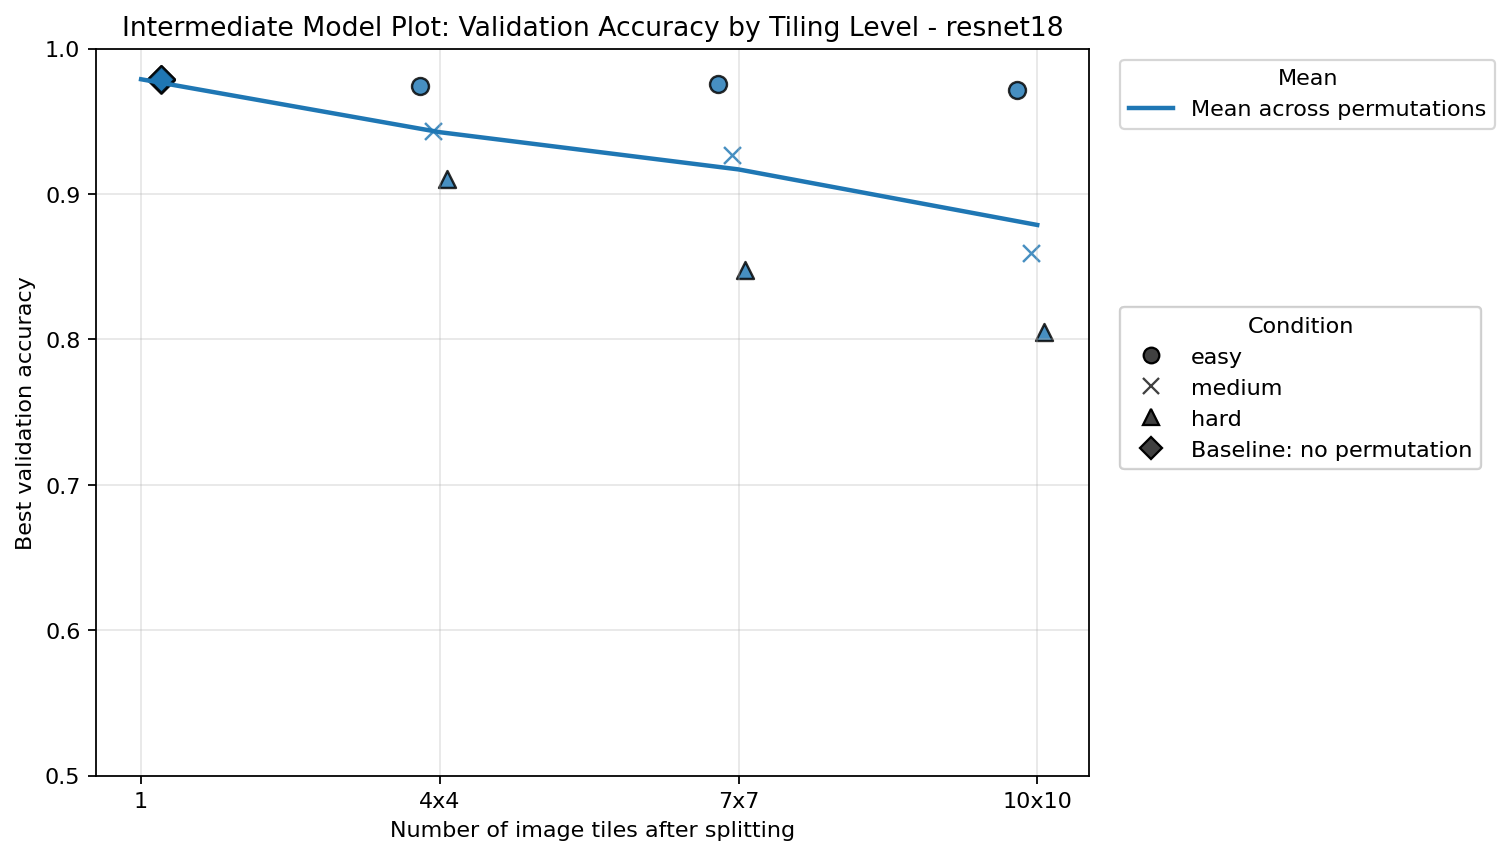

Saved 12 pending row(s) for model 'deit_tiny'.

[1/12]
model=deit_tiny, tiles_per_side=None, tile_permutation_id=1, tile_permutation_name=easy, seed=42
stages=1
1. standard: 10 epochs
Building dataloaders...
Built dataloaders: 
	train=20000 samples in 313 batches
	validation=5000 samples in 79 batches.
Building model 'deit_tiny'...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Runtime: selected_device=cuda, model_device=cuda:0, use_amp=True, amp_enabled=True, cuda_device=NVIDIA L4
Model summary: model=deit_tiny, total_params=5,524,802, trainable_params=386, optimizer_params=386, freeze_backbone=True
Checkpoint complete; skipping step at epoch 10/10: /content/drive/MyDrive/MLDS_Final_Project/outputs/checkpoints/part1/part1/deit_tiny__tiles_1__perm_1__last.pt
Current run runtime: 5s
Total training runtime: 5s

[2/12]
model=deit_tiny, tiles_per_side=None, tile_permutation_id=2, tile_permutation_name=medium, seed=42
stages=1
1. standard: 10 epochs
Building dataloaders...
Built dataloaders: 
	train=20000 samples in 313 batches
	validation=5000 samples in 79 batches.
Building model 'deit_tiny'...
Runtime: selected_device=cuda, model_device=cuda:0, use_amp=True, amp_enabled=True, cuda_device=NVIDIA L4
Model summary: model=deit_tiny, total_params=5,524,802, trainable_params=386, optimizer_params=386, freeze_backbone=True
Checkpoint complete; skipping step at epoch 1

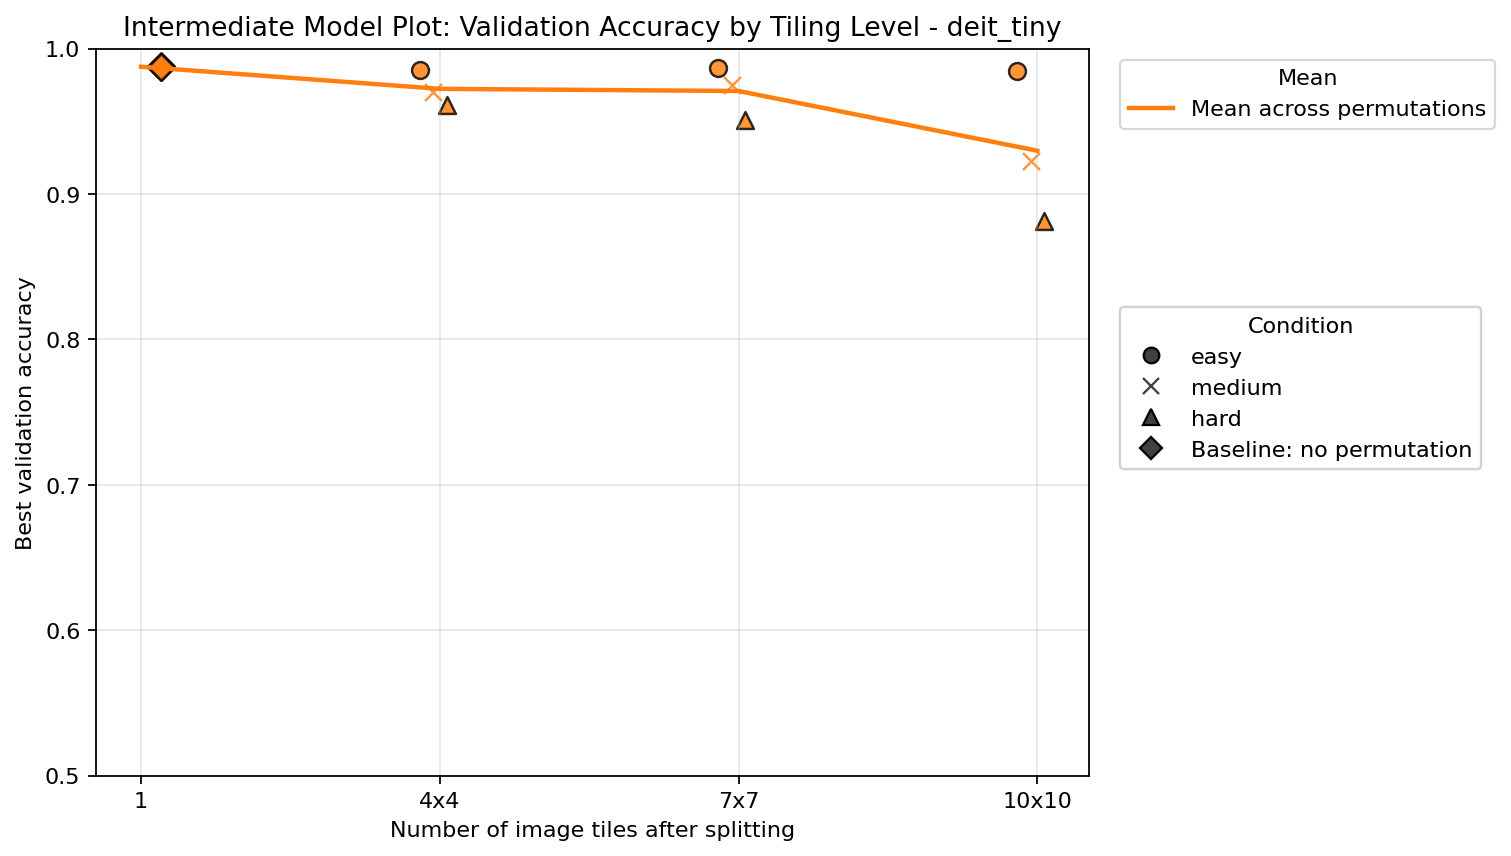

Saved 12 pending row(s) for model 'mlp_mixer_base'.

[1/12]
model=mlp_mixer_base, tiles_per_side=None, tile_permutation_id=1, tile_permutation_name=easy, seed=42
stages=1
1. standard: 10 epochs
Building dataloaders...
Built dataloaders: 
	train=20000 samples in 313 batches
	validation=5000 samples in 79 batches.
Building model 'mlp_mixer_base'...


model.safetensors:   0%|          | 0.00/240M [00:00<?, ?B/s]

Runtime: selected_device=cuda, model_device=cuda:0, use_amp=True, amp_enabled=True, cuda_device=NVIDIA L4
Model summary: model=mlp_mixer_base, total_params=59,113,010, trainable_params=1,538, optimizer_params=1,538, freeze_backbone=True
Checkpoint complete; skipping step at epoch 10/10: /content/drive/MyDrive/MLDS_Final_Project/outputs/checkpoints/part1/part1/mlp_mixer_base__tiles_1__perm_1__last.pt
Current run runtime: 12s
Total training runtime: 12s

[2/12]
model=mlp_mixer_base, tiles_per_side=None, tile_permutation_id=2, tile_permutation_name=medium, seed=42
stages=1
1. standard: 10 epochs
Building dataloaders...
Built dataloaders: 
	train=20000 samples in 313 batches
	validation=5000 samples in 79 batches.
Building model 'mlp_mixer_base'...
Runtime: selected_device=cuda, model_device=cuda:0, use_amp=True, amp_enabled=True, cuda_device=NVIDIA L4
Model summary: model=mlp_mixer_base, total_params=59,113,010, trainable_params=1,538, optimizer_params=1,538, freeze_backbone=True
Checkpoi

mlp_mixer_base 4x4 easy permutation:  50%|#####     | 5/10 [00:00<?, ?epoch/s]

mlp_mixer_base 4x4 easy permutation epoch 6 batches:   0%|          | 0/313 [00:00<?, ?batch/s]

...

mlp_mixer_base 10x10 hard permutation epoch 7 batches:   0%|          | 0/313 [00:00<?, ?batch/s]

mlp_mixer_base 10x10 hard permutation epoch 8 batches:   0%|          | 0/313 [00:00<?, ?batch/s]

mlp_mixer_base 10x10 hard permutation epoch 9 batches:   0%|          | 0/313 [00:00<?, ?batch/s]

mlp_mixer_base 10x10 hard permutation epoch 10 batches:   0%|          | 0/313 [00:00<?, ?batch/s]

Current run runtime: 19m 24s
Total training runtime: 2h 35m 54s
Saved intermediate model plot: /content/drive/MyDrive/MLDS_Final_Project/outputs/figures/intermediate/part1_accuracy_vs_tiles_mlp_mixer_base.png
Completed training mlp_mixer_base with 12 runs


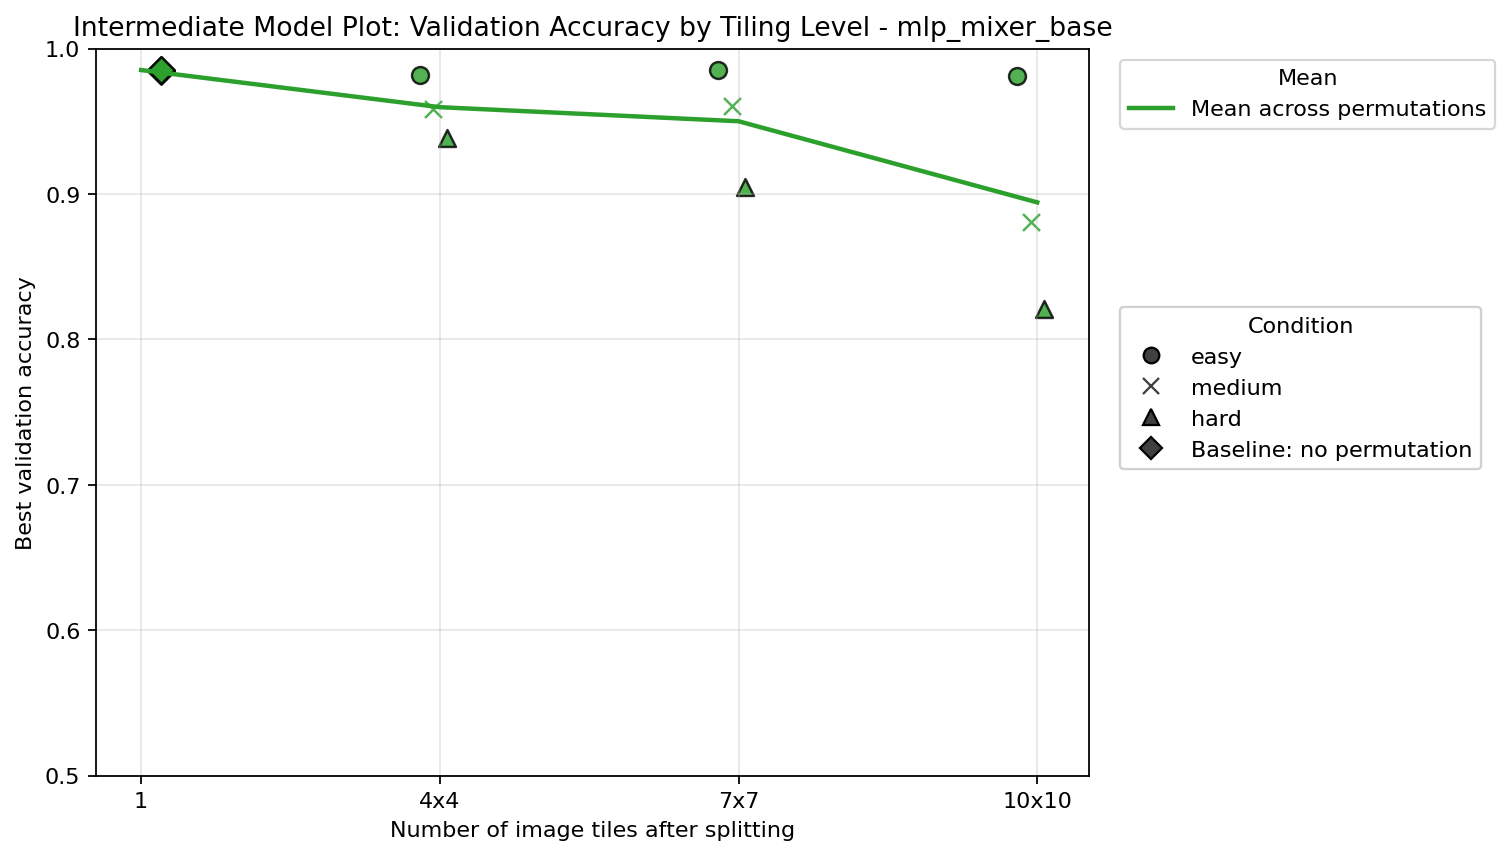

In [17]:
for model_name in configs.model_names:
    intermediate_figure_path = experiment_intermediate_figure_path(
        configs.figures_dir,
        configs.part,
        f'accuracy_vs_tiles_{model_name}',
    )
    rows = train_model_on_tile_permutation_records(
        config=configs,
        model_name=model_name,
        run_id=run_id,
        train_samples=train_samples,
        validation_samples=validation_samples,
        tile_permutation_records=tile_permutation_records,
        seed=seed,
        device=device,
        raw_results_output_path=output_paths["raw_results"],
        intermediate_figure_output_path=intermediate_figure_path,
    )
    all_rows.extend(rows)
    print("Completed training", model_name, "with", len(rows), "runs")
    if Path(intermediate_figure_path).exists():
        display(Image(filename=intermediate_figure_path))


In [18]:
# Aggregate results and plot
raw_results = pd.read_csv(filepath_or_buffer=output_paths['raw_results'])
aggregated_results = save_aggregated_accuracy(
    raw_results=raw_results,
    group_columns=['model_name', 'tiles_per_side', 'num_tiles'],
    output_path=output_paths['aggregated_results'],
)
plot_accuracy_vs_tiles(
    aggregated=aggregated_results,
    output_path=output_paths['accuracy_plot'],
    raw_results=raw_results,
)
aggregated_results

,model_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,deit_tiny,4.0,16,0.971467,0.012290,0.972267,0.012307,3
1,deit_tiny,7.0,49,0.970533,0.018309,0.970800,0.018399,3
2,deit_tiny,10.0,100,0.928400,0.052571,0.929733,0.051948,3
3,deit_tiny,NaN,1,0.987467,0.000306,0.987467,0.000306,3
4,mlp_mixer_base,4.0,16,0.958667,0.022504,0.959667,0.021637,3
5,mlp_mixer_base,7.0,49,0.949133,0.040549,0.950000,0.041257,3
6,mlp_mixer_base,10.0,100,0.893333,0.081597,0.894200,0.080987,3
7,mlp_mixer_base,NaN,1,0.984533,0.000115,0.985200,0.000346,3
8,resnet18,4.0,16,0.942333,0.031903,0.942467,0.031906,3
9,resnet18,7.0,49,0.916000,0.065867,0.916867,0.064476,3


### Experiments - Results Table
Reload the saved aggregated CSV so the report is reproducible from disk. Each row averages all tile permutation scores for the same model and tile count.


In [19]:
saved_results = {
    'raw': pd.read_csv(filepath_or_buffer=output_paths['raw_results']),
    'aggregated': pd.read_csv(filepath_or_buffer=output_paths['aggregated_results']),
}
display(saved_results['aggregated'])

,model_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,deit_tiny,4.0,16,0.971467,0.012290,0.972267,0.012307,3
1,deit_tiny,7.0,49,0.970533,0.018309,0.970800,0.018399,3
2,deit_tiny,10.0,100,0.928400,0.052571,0.929733,0.051948,3
3,deit_tiny,NaN,1,0.987467,0.000306,0.987467,0.000306,3
4,mlp_mixer_base,4.0,16,0.958667,0.022504,0.959667,0.021637,3
5,mlp_mixer_base,7.0,49,0.949133,0.040549,0.950000,0.041257,3
6,mlp_mixer_base,10.0,100,0.893333,0.081597,0.894200,0.080987,3
7,mlp_mixer_base,NaN,1,0.984533,0.000115,0.985200,0.000346,3
8,resnet18,4.0,16,0.942333,0.031903,0.942467,0.031906,3
9,resnet18,7.0,49,0.916000,0.065867,0.916867,0.064476,3


### Experiments - Accuracy Plot
Display the saved accuracy-vs-number-of-tiles plot.


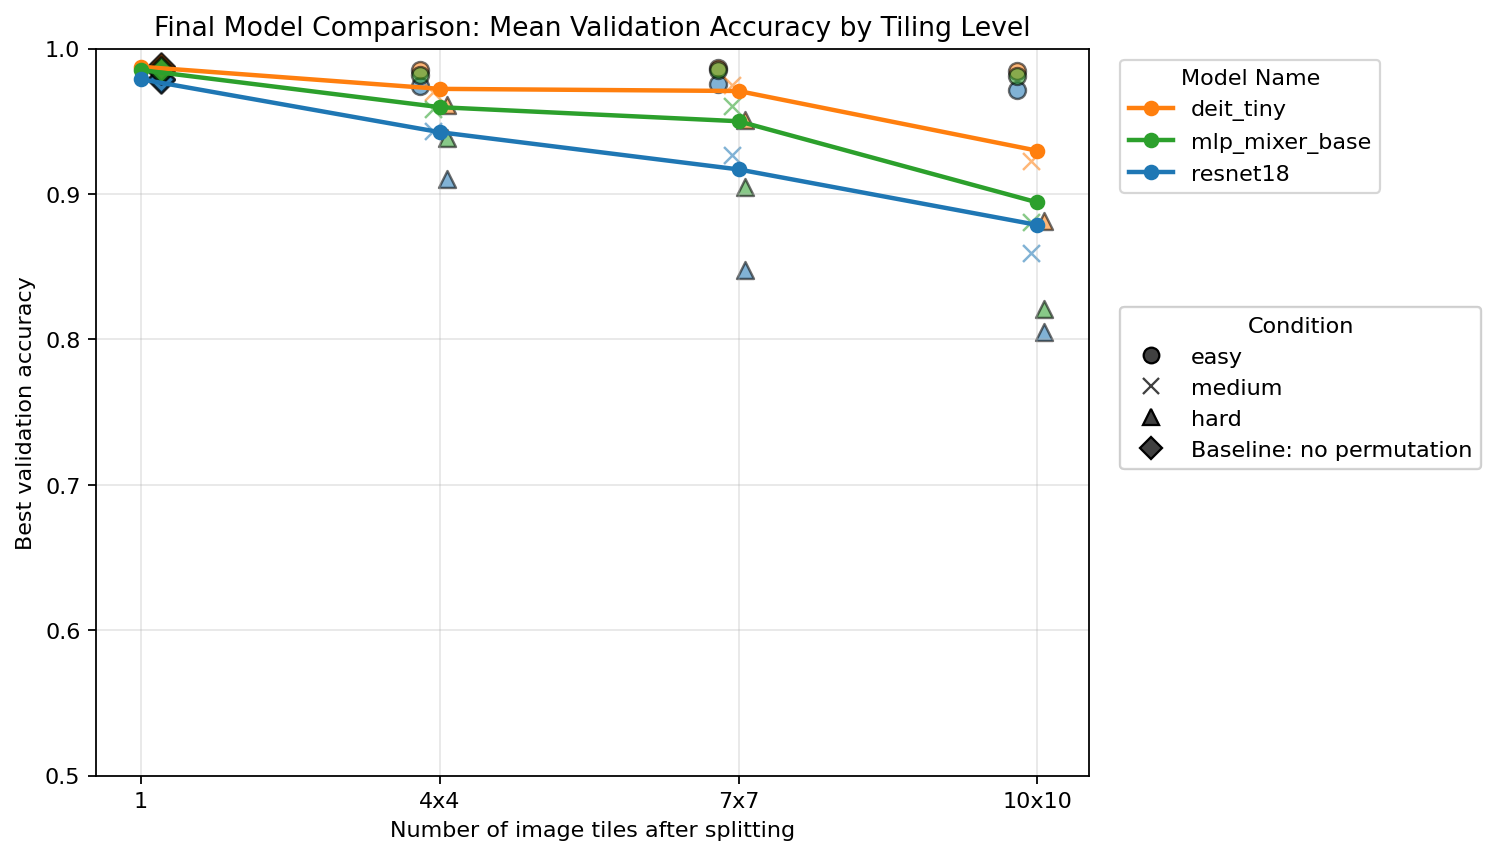

In [20]:
figure_path = output_paths['accuracy_plot']
if Path(figure_path).exists():
    display(Image(filename=figure_path))
else:
    print(f'Plot not found yet: {figure_path}')


In [21]:
# Export this saved notebook to PDF. Save the notebook before running this cell,
# because nbconvert reads the on-disk .ipynb file rather than unsaved editor state.
import importlib

import src.utils.notebook_setup as notebook_setup

notebook_setup = importlib.reload(notebook_setup)
notebook_path = ROOT / 'src' / 'notebooks' / 'part1_solution.ipynb'
export_dir = ROOT / 'outputs' / 'notebooks'
notebook_setup.export_notebook_to_pdf(notebook_path, export_dir)


FileNotFoundError: [Errno 2] No such file or directory: 'kpsewhich'